In [1]:
from pgmpy.models import BayesianNetwork

from pgmpy.estimators import HillClimbSearch, BDsScore
from pgmpy.factors.discrete import State
import numpy as np
import pandas as pd

import pdb

import itertools
import pysmile
import pysmile_license

c:\Users\danie\anaconda3\envs\crc_incentives\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
net2 = pysmile.Network()
net2.read_file(f"../models/DM_screening_rel_point_cond_mut_info_linear.xdsl")
net2.clear_all_evidence()

patient_chars = {
"Age": "age_5_old_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "False",
"Hypertension": "False",
}

for key, value in patient_chars.items():
    net2.set_evidence(key, value)

net2.update_beliefs()

p_crc = net2.get_node_value("CRC")[1]
p_no_crc = net2.get_node_value("CRC")[0]

vars1 = net2.get_outcome_ids("Screening")
arr = np.array(net2.get_node_value("Screening"))
df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

# take column with the highest value
scr = df_scr.idxmax(axis=1).values[0]
scr_decision_patient = ["No_screening", scr]

print(f"Patient decision: {scr_decision_patient}")
print(f"Probability of CRC: {p_crc}")

Patient decision: ['No_screening', 'Stool_DNA']
Probability of CRC: 0.002235155200821302


In [143]:
import numpy as np


u_EQ5D = {
    "age_1_young_adult": 0.966,
    "age_2_young": 0.963,
    "age_3_young_adult": 0.939,
    "age_4_adult": 0.911,
    "age_5_old_adult": 0.884,
}

def EQ5D(age):
    return u_EQ5D[age]


scr_costs_dict = {
    "No_screening": 0,
    "gFOBT": 12.14,
    "FIT": 14.34,
    "Blood_based": 123.13,
    "Stool_DNA": 236.88,
    "CTC": 95.41,
    "CC": 510.24,
    "Colonoscopy": 1000
}

def scr_costs(scr):
    return scr_costs_dict[scr]

sensitivity_dict = {
    "No_screening": 0,
    "gFOBT": 0.45,
    "FIT": 0.75,
    "Blood_based": 0.66,
    "Stool_DNA": 0.923,
    "CTC": 0.8,
    "CC": 0.87,
    "Colonoscopy": 0.97
}

def sensitivity(scr):
    return sensitivity_dict[scr]

specificity_dict = {
    "No_screening": 1,
    "gFOBT": 0.978,
    "FIT": 0.966,
    "Blood_based": 0.91,
    "Stool_DNA": 0.866,
    "CTC": 0.89,
    "CC": 0.92,
    "Colonoscopy": 0.99
}

def specificity(scr):
    return specificity_dict[scr]

comfort_dict = {
    "No_screening": 4,
    "gFOBT": 3,
    "FIT": 3,
    "Blood_based": 3,
    "Stool_DNA": 3,
    "CTC": 2,
    "CC": 2,
    "Colonoscopy": 1
}

def comfort(scr):
    return comfort_dict[scr]


def diff_QALY(crc, r_scr):
    if crc == 1 and r_scr == 1:
        return np.random.uniform(5, 10)
    elif crc == 1 and r_scr == 0:
        return - np.random.uniform(3, 5)
    else:
        return 0 
    
    
def cost_SP(age, crc, scr, scr_decision, r_scr, K):
    if scr == "No_screening" or scr_decision == 0:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) - K - scr_costs(scr) - 25955*crc*r_scr

def cost_cit(age, crc, scr, r_scr, K, cit_comfort_noise=None):
    if isinstance(crc, np.ndarray):
        val_QALY = 30968 * EQ5D(age) * np.array([diff_QALY(c, r) for c, r in zip(crc, r_scr)])
    else:
        val_QALY = 30968 * EQ5D(age) * diff_QALY(crc, r_scr)
    if scr == "No_screening":
        return val_QALY
    else:
        return val_QALY + K - (cit_comfort_noise / comfort(scr)) - 5000 * r_scr


# Define how much each age group underestimates their risk

age_underestimation_factors = {
    "age_1_young_adult": 0.1,  # Perceives 10% of their actual risk
    "age_2_young": 0.2,        # Perceives 20% of their actual risk
    "age_3_young_adult": 0.3,  # Perceives 30% of their actual risk
    "age_4_adult": 0.5,        # Perceives 50% of their actual risk
    "age_5_old_adult": 0.7     # Perceives 80% of their actual risk
}


def prob_crc_cit(true_p_crc, age):
    base_factor = age_underestimation_factors[age]
    
    # Add a little uniform noise so not everyone in the age group is identical
    factor = base_factor * np.random.uniform(0.9999, 1.0001)
    factor = min(max(factor, 0.01), 0.99)
    
    r = true_p_crc * factor
    if r <= 0:
        return 0
        
    var = (r * 0.01)**2
    
    d1 = ((1-r)/var - 1/r)*r**2
    d2 = d1*(1/r - 1)
    
    if d1 <= 0 or d2 <= 0:
        return r
        
    return np.random.beta(d1, d2)

def random_utilities_SP(cost, mu_alpha=-20, sigma_alpha=0.1):
    # 2. Sample the parameter internally
    sampled_alphas = np.random.lognormal(mean=mu_alpha, sigma=sigma_alpha)
    
    # 3. Calculate the utility using the sampled parameters
    u_sampled_SP = 1 - np.exp(-sampled_alphas * cost)
    
    return u_sampled_SP

def random_utilities_cit(sampled_alphas, age, crc, scr, r_scr, K, cit_comfort_noise=None):
    cost = cost_cit(age, crc, scr, r_scr, K, cit_comfort_noise)
    
    #exponent = np.clip(-sampled_alphas * cost, -700, 700)

    #u_sampled_SP = 1 - np.exp(exponent)
    u_sampled_SP = cost
    
    return u_sampled_SP

### Citizen prob of accepting scr varying K

Optimal screening: Stool_DNA
p_crc = 0.004035150326944915
K = 0, mean_p_scr = 0.6142, median_p_scr = 0.6100
K = 1, mean_p_scr = 0.6137, median_p_scr = 0.6150
K = 50, mean_p_scr = 0.7497, median_p_scr = 0.7450
K = 100, mean_p_scr = 0.8724, median_p_scr = 0.8700
K = 200, mean_p_scr = 0.9940, median_p_scr = 0.9950


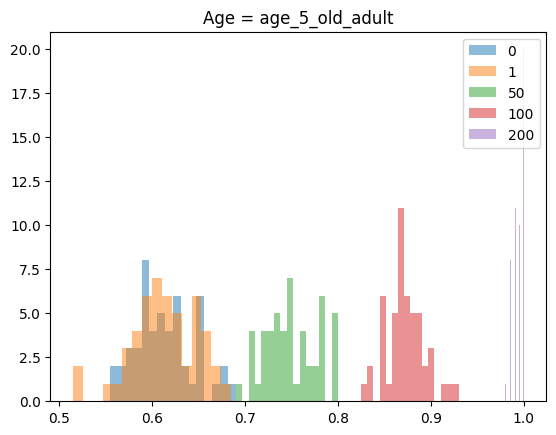

In [152]:
import matplotlib.pyplot as plt
N_ara = 200  # Number of ARA samples (principal's uncertainty about this specific citizen's private parameters)
N_mc_evals = 50  # Number of MC draws the citizen uses to compute their own Expected Utility

# def plot_histograms_count_distrib(net2, patient_chars):

for key, value in patient_chars.items():
    net2.set_evidence(key, value)

net2.update_beliefs()

p_crc = net2.get_node_value("CRC")[1]
p_no_crc = net2.get_node_value("CRC")[0]

vars1 = net2.get_outcome_ids("Screening")
arr = np.array(net2.get_node_value("Screening"))
df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

# take column with the highest value
scr = df_scr.idxmax(axis=1).values[0]
scr_decision_patient = ["No_screening", scr]

print(f"Optimal screening: {scr}")
print(f"p_crc = {p_crc}")

# We are evaluating ONE specific citizen defined by patient_chars
age = patient_chars["Age"]

for ind_k, k in enumerate([0 , 1, 50, 100, 200]):
    plt_arr = []

    # We calculate the probability of THIS specific citizen accepting screening.
    # We loop 20 times just to generate a histogram of that probability to verify stability.
    for _ in range(50):
        accept_count = 0
        
        # ARA loop: Simulate unknown private parameters characterizing THIS citizen
        for _ in range(N_ara):
            # Draw citizen's private beliefs and preferences
            p_belief = prob_crc_cit(p_crc, age) 
            cit_comfort_noise = 300 * np.random.normal(1.0, 0.2)
            
            expected_utilities = np.zeros((len(scr_decision_patient), ))

            sampled_alphas_cit = np.random.lognormal(mean=-2, sigma=0.1)
            
            # NOTE: MC loop or analytical calculation????
            #pdb.set_trace()
            expected_utilities = np.array( [
                    sensitivity(scr_) * prob_crc_cit(p_crc, age) * random_utilities_cit(sampled_alphas_cit, age, crc=1, r_scr=1, scr = scr_, K=k, cit_comfort_noise=cit_comfort_noise) +
                    (1 - specificity(scr_)) * (1-prob_crc_cit(p_crc, age)) * random_utilities_cit(sampled_alphas_cit, age, crc=0, r_scr=1, scr = scr_, K=k, cit_comfort_noise=cit_comfort_noise)
                +
                    (1 - sensitivity(scr_)) * prob_crc_cit(p_crc, age) * random_utilities_cit(sampled_alphas_cit, age, crc=1, r_scr=0, scr = scr_, K=k, cit_comfort_noise=cit_comfort_noise) +
                    specificity(scr_) * (1-prob_crc_cit(p_crc, age)) * random_utilities_cit(sampled_alphas_cit, age, crc=0, r_scr=0, scr = scr_, K=k, cit_comfort_noise=cit_comfort_noise)
                for scr_ in scr_decision_patient] )

            # The citizen evaluates the EXPECTED utility of their choices
            '''for f in range(N_mc_evals):
                c_sim = np.random.binomial(1, p_belief)

                for j_s, scr_ in enumerate(scr_decision_patient):
                    r_sim = np.random.binomial(1, sensitivity(scr_) * c_sim + (1 - specificity(scr_)) * (1 - c_sim))
                    payoff = cost_cit(age=age, crc=c_sim, scr=scr_, r_scr=r_sim, K=k, cit_comfort_noise=cit_comfort_noise)
                    
                    expected_utilities[j_s] += payoff # random_utilities_cit(payoff)
            
            expected_utilities /= N_mc_evals'''
            # pdb.set_trace()
            # Citizen's decision happens *once* based on their full Expected Utility
            if np.argmax(expected_utilities) == 1:
                accept_count += 1

        # Probability THIS citizen accepts screening at this K
        p_scr = accept_count / N_ara
        plt_arr.append(p_scr)

    plt_arr = np.array(plt_arr)
    # for each K, plot the distribution of p_scr with a different color
    plt.hist(plt_arr, bins = 16 , alpha=0.5, label=str(k))
    plt.legend(loc='upper right')
    plt.title("Age = " + age)
    print(f"K = {k}, mean_p_scr = {np.mean(plt_arr):.4f}, median_p_scr = {np.median(plt_arr):.4f}")
    
plt.show()

In [147]:
expected_utilities

array([-242.65253248,  -41.96682187])

Optimal screening: Stool_DNA
p_crc = 0.004035150326944915
K = 0, mean_p_scr = 0.7937, median_p_scr = 0.7900
K = 1, mean_p_scr = 0.8018, median_p_scr = 0.8050
K = 50, mean_p_scr = 0.9075, median_p_scr = 0.9100
K = 100, mean_p_scr = 0.9777, median_p_scr = 0.9800
K = 200, mean_p_scr = 1.0000, median_p_scr = 1.0000


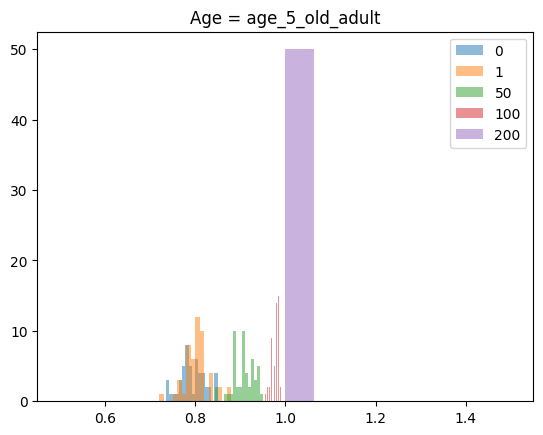

In [148]:
patient_chars = {
"Age": "age_5_old_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_1",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "True",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)

Optimal screening: Stool_DNA
p_crc = 0.0019217266847467002
K = 0, mean_p_scr = 1.0000, median_p_scr = 1.0000
K = 1, mean_p_scr = 1.0000, median_p_scr = 1.0000
K = 50, mean_p_scr = 1.0000, median_p_scr = 1.0000
K = 100, mean_p_scr = 1.0000, median_p_scr = 1.0000
K = 200, mean_p_scr = 1.0000, median_p_scr = 1.0000


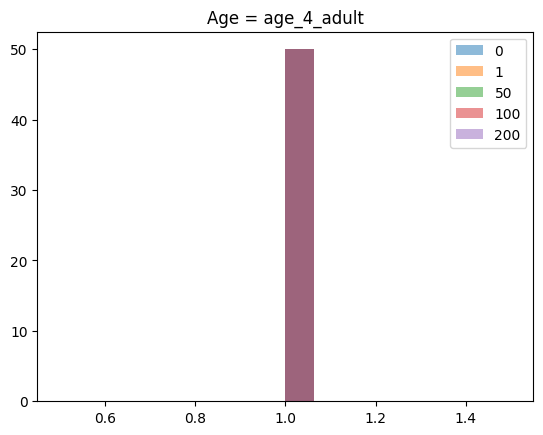

In [110]:
patient_chars = {
"Age": "age_4_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "True",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)